# Supervised classification — Hypo vs Norm

For each of the four datasets we:

1. Split a held-out validation set (stratified 80/20).
2. Train **Logistic Regression**, **Random Forest**, **SVM** with 5-fold
   stratified cross-validation on the training portion.
3. Score with **accuracy**, **F1**, **ROC AUC** and a confusion matrix.
4. Refit the best model on the full training set, predict on the **anonymised
   test set** and persist the predictions to `results/`.
5. Additional genes analysis

In [13]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[1]))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="notebook", style="whitegrid")
RNG = 42

In [14]:
from src.utils import load_smartseq, load_dropseq

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
)

## 1 — Assemble the four datasets

In [15]:
DATASETS = {
    "MCF7_SmartSeq": lambda: load_smartseq("MCF7"),
    "HCC1806_SmartSeq": lambda: load_smartseq("HCC1806"),
    "MCF7_DropSeq": lambda: load_dropseq("MCF7"),
    "HCC1806_DropSeq": lambda: load_dropseq("HCC1806"),
}
TEST_LOADERS = {
    "MCF7_SmartSeq": lambda: load_smartseq("MCF7", split="test"),
    "HCC1806_SmartSeq": lambda: load_smartseq("HCC1806", split="test"),
    "MCF7_DropSeq": lambda: load_dropseq("MCF7", split="test"),
    "HCC1806_DropSeq": lambda: load_dropseq("HCC1806", split="test"),
}

## 2 — Model definitions

In [ ]:
def make_models(random_state=RNG):
    return {
        "logreg": Pipeline(
            [("scale", StandardScaler()), ("clf", LogisticRegression(max_iter=2000, C=1.0, random_state=random_state))]
        ),
        "rf": Pipeline([("clf", RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=random_state))]),
        "svm_rbf": Pipeline(
            [
                ("scale", StandardScaler()),
                ("pca", PCA(n_components=50, random_state=random_state)),
                ("clf", SVC(C=1.0, kernel="rbf", probability=True, random_state=random_state)),
            ]
        ),
    }

## 3 — Cross-validate every (model × dataset)

In [17]:
cv_records = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
for ds_name, loader in DATASETS.items():
    X_df, y_ser = loader()
    X = X_df.values
    y = LabelEncoder().fit_transform(y_ser)  # Hypo=0, Norm=1 (alphabetic)
    for model_name, model in make_models().items():
        scores = cross_validate(
            model,
            X,
            y,
            cv=skf,
            scoring=["accuracy", "f1", "roc_auc"],
            n_jobs=-1,
            return_train_score=False,
        )
        for fold in range(5):
            cv_records.append(
                {
                    "dataset": ds_name,
                    "model": model_name,
                    "fold": fold,
                    "accuracy": scores["test_accuracy"][fold],
                    "f1": scores["test_f1"][fold],
                    "roc_auc": scores["test_roc_auc"][fold],
                }
            )
    print(f"✓ CV done for {ds_name}")
cv_df = pd.DataFrame(cv_records)
cv_summary = cv_df.groupby(["dataset", "model"])[["accuracy", "f1", "roc_auc"]].agg(["mean", "std"]).round(3)
cv_summary

✓ CV done for MCF7_SmartSeq
✓ CV done for HCC1806_SmartSeq
✓ CV done for MCF7_DropSeq
✓ CV done for HCC1806_DropSeq


accuracy            f1        roc_auc       
                             mean    std   mean    std    mean    std
dataset          model                                               
HCC1806_DropSeq  logreg     0.920  0.006  0.901  0.007   0.974  0.004
                 rf         0.935  0.002  0.912  0.003   0.989  0.001
                 svm_rbf    0.954  0.004  0.942  0.006   0.991  0.001
HCC1806_SmartSeq logreg     0.939  0.031  0.935  0.033   0.987  0.014
                 rf         0.989  0.015  0.988  0.016   0.999  0.001
                 svm_rbf    0.951  0.030  0.948  0.031   0.989  0.015
MCF7_DropSeq     logreg     0.961  0.003  0.967  0.002   0.993  0.001
                 rf         0.967  0.002  0.973  0.002   0.994  0.001
                 svm_rbf    0.979  0.001  0.982  0.001   0.998  0.000
MCF7_SmartSeq    logreg     1.000  0.000  1.000  0.000   1.000  0.000
                 rf         1.000  0.000  1.000  0.000   1.000  0.000
                 svm_rbf    1.000  0.000  1.000  0.000   1.000  0.000

/var/folders/nr/mb9t16753gl29cqg5ry9kft00000gn/T/ipykernel_3080/616936422.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
/var/folders/nr/mb9t16753gl29cqg5ry9kft00000gn/T/ipykernel_3080/616936422.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
/var/folders/nr/mb9t16753gl29cqg5ry9kft00000gn/T/ipykernel_3080/616936422.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")


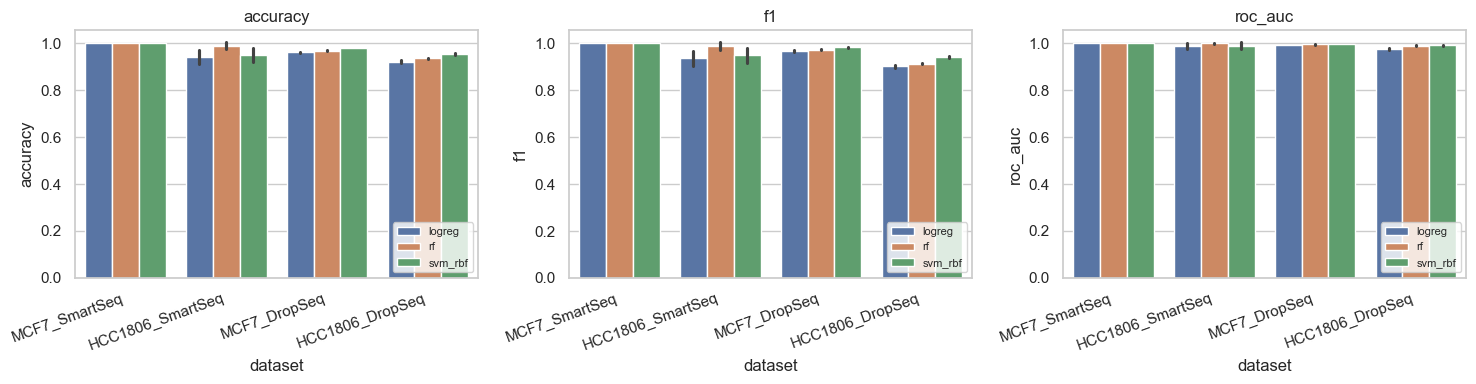

In [18]:
# Plot CV scores side-by-side.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["accuracy", "f1", "roc_auc"]):
    sns.barplot(data=cv_df, x="dataset", y=metric, hue="model", ax=ax, errorbar="sd")
    ax.set_title(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
    ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 4 — Feature selection: how many genes do we actually need?

In [ ]:
ks = [10, 25, 50, 100, 250, 500, 1000, 3000]
skf_fs = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
fs_records = []
for ds_name, loader in DATASETS.items():
    X_df, y_ser = loader()
    X, y = X_df.values, LabelEncoder().fit_transform(y_ser)
    for k in ks:
        pipe = Pipeline(
            [
                ("select", SelectKBest(f_classif, k=min(k, X.shape[1]))),
                ("scale", StandardScaler()),
                ("clf", LogisticRegression(max_iter=2000, random_state=RNG)),
            ]
        )
        sc = cross_validate(pipe, X, y, cv=skf_fs, scoring=["roc_auc", "f1"], n_jobs=-1)
        fs_records.append(
            {"dataset": ds_name, "k": k, "roc_auc": sc["test_roc_auc"].mean(), "f1": sc["test_f1"].mean()}
        )
    print(f"✓ feature-selection sweep done for {ds_name}")
fs_df = pd.DataFrame(fs_records)
fs_df.pivot(index="k", columns="dataset", values="roc_auc").round(3)

/Users/gift/Projects/Python_projects/AI_Lab/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [1850] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/gift/Projects/Python_projects/AI_Lab/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/gift/Projects/Python_projects/AI_Lab/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [1850] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/gift/Projects/Python_projects/AI_Lab/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/gift/Projects/Python_projects/AI_Lab/.venv/lib/python3.12/site-pack

✓ feature-selection sweep done for MCF7_SmartSeq
✓ feature-selection sweep done for HCC1806_SmartSeq
✓ feature-selection sweep done for MCF7_DropSeq


/Users/gift/Projects/Python_projects/AI_Lab/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [2324] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/gift/Projects/Python_projects/AI_Lab/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/gift/Projects/Python_projects/AI_Lab/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [1293 2513] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/gift/Projects/Python_projects/AI_Lab/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/gift/Projects/Python_projects/AI_Lab/.venv/lib/python3.12/site

✓ feature-selection sweep done for HCC1806_DropSeq


dataset,HCC1806_DropSeq,HCC1806_SmartSeq,MCF7_DropSeq,MCF7_SmartSeq
k,,,,
10,0.915,0.991,0.960,1.0
25,0.963,0.993,0.980,1.0
50,0.977,0.992,0.988,1.0
100,0.984,0.997,0.996,1.0
250,0.989,0.993,0.997,1.0
500,0.989,0.999,0.996,1.0
1000,0.980,0.990,0.993,1.0
3000,0.974,0.987,0.993,1.0


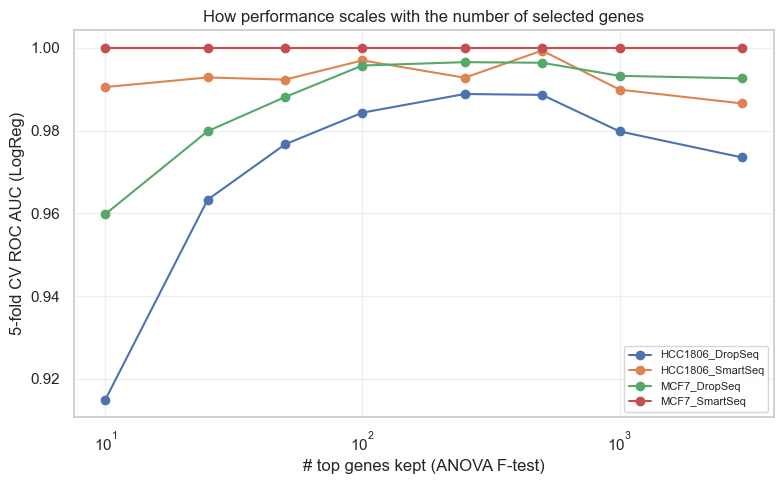

In [20]:
# ROC AUC vs number of genes kept, one line per dataset.
plt.figure(figsize=(8, 5))
for ds_name, sub in fs_df.groupby("dataset"):
    plt.plot(sub["k"], sub["roc_auc"], "o-", label=ds_name)
plt.xscale("log")
plt.xlabel("# top genes kept (ANOVA F-test)")
plt.ylabel("5-fold CV ROC AUC (LogReg)")
plt.title("How performance scales with the number of selected genes")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# Top-25 by ANOVA F-stat per dataset.
for ds_name, loader in DATASETS.items():
    X_df, y_ser = loader()
    sel = SelectKBest(f_classif, k=25).fit(X_df.values, LabelEncoder().fit_transform(y_ser))
    top = X_df.columns[sel.get_support()].tolist()
    print(f"{ds_name}: {top}")

MCF7_SmartSeq: ['NDRG1', 'BNIP3', 'MT-CYB', 'MT-CO3', 'GPI', 'MT-CO2', 'PGK1', 'LDHA', 'DYNC2I2', 'MT-ATP6', 'FAM162A', 'ARPC1B', 'SRM', 'PFKP', 'GAPDH', 'HNRNPA2B1', 'FDPS', 'DCXR', 'MT-ATP8', 'SLC25A39', 'PSME2', 'SNRNP25', 'PGP', 'MTATP6P1', 'ALDOA']
HCC1806_SmartSeq: ['DDIT4', 'NDRG1', 'EGLN3', 'CA9', 'BNIP3', 'BHLHE40', 'ALDOC', 'SLC2A1', 'PGK1', 'SLC6A8', 'LOXL2', 'PFKFB3', 'LDHA', 'ERO1A', 'P4HA1', 'MOB3A', 'GPI', 'ALDOA', 'PLOD2', 'ENO2', 'BNIP3L', 'TPBG', 'C4orf3', 'EGLN1', 'FAM162A']
MCF7_DropSeq: ['MT-RNR2', 'TFF1', 'MT-RNR1', 'TMSB10', 'RPS5', 'LGALS1', 'RPL12', 'RPL39', 'RPL35', 'RPS19', 'RPL36', 'RPL13', 'TPI1', 'S100A10', 'RPL35A', 'KRT19', 'RPS14', 'RPL34', 'ROMO1', 'RPL15', 'GAPDH', 'TMEM258', 'PGK1', 'RPL30', 'RPLP1']
HCC1806_DropSeq: ['BCYRN1', 'IGFBP3', 'NDRG1', 'GPM6A', 'FGF23', 'AKR1C2', 'TMSB10', 'LDHA', 'NCL', 'NCALD', 'BNIP3', 'B4GALT1', 'P4HA1', 'RPL41', 'PGK1', 'S100A10', 'HSP90AB1', 'NPM1P40', 'CACNA1A', 'HSPD1', 'AKR1C1', 'HSP90AA1', 'WDR43', 'CALM2', 'EIF3

Two things to discuss in the report:

- **Saturation point**: ROC AUC typically plateaus well before 3000 genes —
  often a few hundred genes carry essentially all the signal. That justifies
  feature selection both for speed and for a more interpretable model.
- **Identity of the top genes**: on SmartSeq the top-ranked genes include
  canonical HIF targets (VEGFA, CA9, BNIP3, ...), confirming the classifier
  keys on real hypoxia biology rather than a technical artefact. Compare the
  lists across datasets — how much do they overlap between the two cell lines?

## 5 — Hold-out evaluation for each dataset

In [22]:
holdout_records = []
confusion_storage = {}
for ds_name, loader in DATASETS.items():
    X_df, y_ser = loader()
    le = LabelEncoder().fit(y_ser)
    X, y = X_df.values, le.transform(y_ser)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RNG)
    for model_name, model in make_models().items():
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model.named_steps["clf"], "predict_proba") else None
        rec = {
            "dataset": ds_name,
            "model": model_name,
            "accuracy": accuracy_score(y_te, y_pred),
            "f1": f1_score(y_te, y_pred),
            "roc_auc": roc_auc_score(y_te, y_prob) if y_prob is not None else np.nan,
        }
        holdout_records.append(rec)
        confusion_storage[(ds_name, model_name)] = (confusion_matrix(y_te, y_pred), le.classes_)
holdout_df = pd.DataFrame(holdout_records).set_index(["dataset", "model"]).round(3)
holdout_df

accuracy     f1  roc_auc
dataset          model                            
MCF7_SmartSeq    logreg      1.000  1.000    1.000
                 rf          1.000  1.000    1.000
                 svm_rbf     1.000  1.000    1.000
HCC1806_SmartSeq logreg      0.946  0.944    0.915
                 rf          1.000  1.000    1.000
                 svm_rbf     0.946  0.944    0.988
MCF7_DropSeq     logreg      0.959  0.965    0.991
                 rf          0.970  0.975    0.995
                 svm_rbf     0.982  0.985    0.999
HCC1806_DropSeq  logreg      0.915  0.895    0.973
                 rf          0.937  0.914    0.990
                 svm_rbf     0.947  0.933    0.989

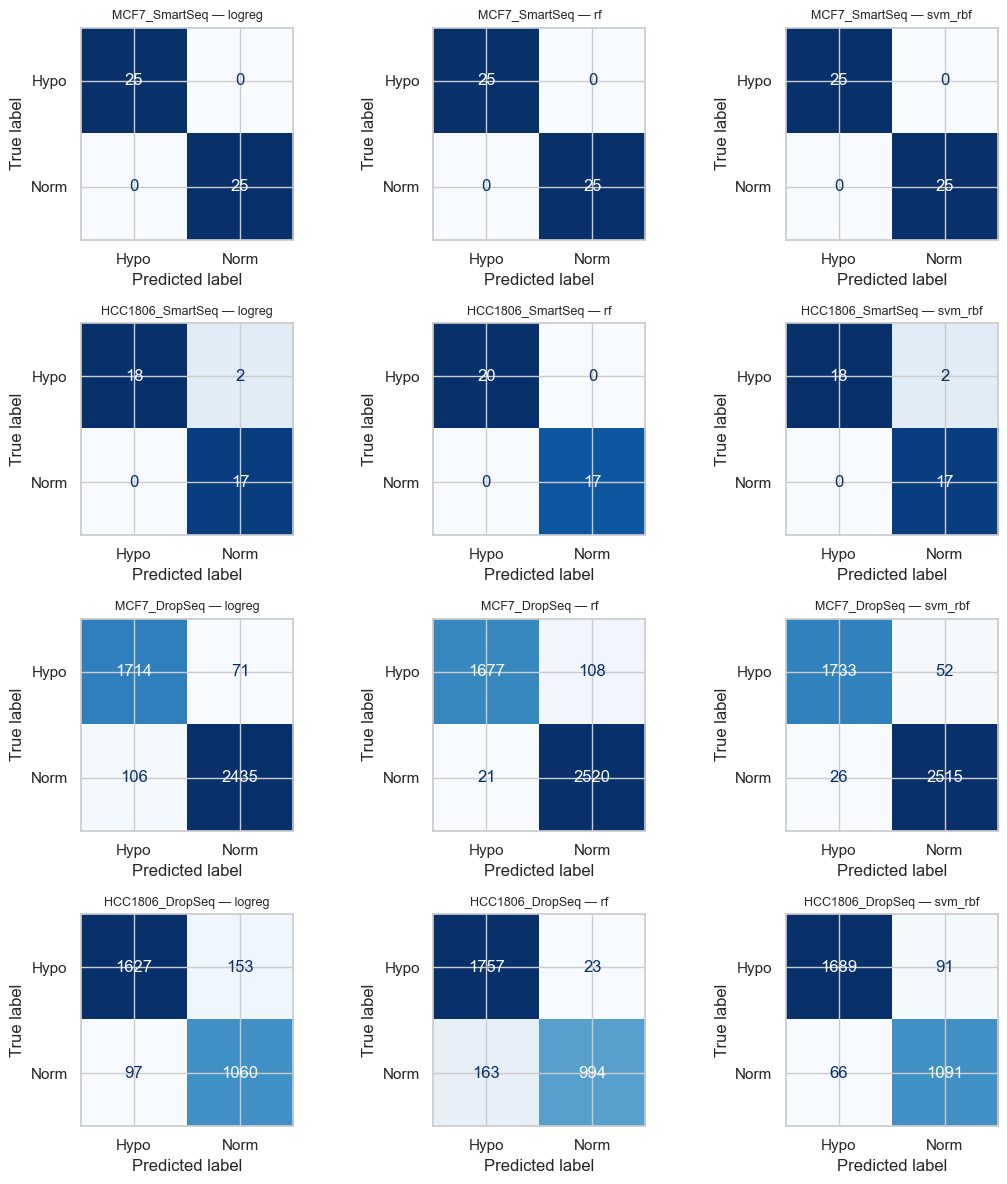

In [23]:
# Confusion matrices, one row per dataset.
fig, axes = plt.subplots(len(DATASETS), 3, figsize=(11, 3 * len(DATASETS)))
for i, ds_name in enumerate(DATASETS):
    for j, model_name in enumerate(["logreg", "rf", "svm_rbf"]):
        cm, classes = confusion_storage[(ds_name, model_name)]
        disp = ConfusionMatrixDisplay(cm, display_labels=classes)
        disp.plot(ax=axes[i, j], colorbar=False, cmap="Blues")
        axes[i, j].set_title(f"{ds_name} — {model_name}", fontsize=9)
plt.tight_layout()
plt.show()

## 6 — Prediction on the anonymised test set

In [24]:
from pathlib import Path

out_dir = Path("../../results")
out_dir.mkdir(exist_ok=True)
champion = (
    holdout_df.reset_index().sort_values(["dataset", "roc_auc"], ascending=[True, False]).groupby("dataset").head(1)
)
print("Champion per dataset:")
print(champion[["dataset", "model", "accuracy", "f1", "roc_auc"]].to_string(index=False))

predictions_summary = []
for _, row in champion.iterrows():
    ds_name, model_name = row["dataset"], row["model"]
    X_train_df, y_train_ser = DATASETS[ds_name]()
    X_test_df, _ = TEST_LOADERS[ds_name]()
    le = LabelEncoder().fit(y_train_ser)
    model = make_models()[model_name]
    model.fit(X_train_df.values, le.transform(y_train_ser))
    y_pred_int = model.predict(X_test_df.values)
    y_pred_lbl = le.inverse_transform(y_pred_int)
    out = pd.DataFrame({"cell_id": X_test_df.index, "predicted_condition": y_pred_lbl})
    out_path = out_dir / f"predictions_{ds_name}.csv"
    out.to_csv(out_path, index=False)
    predictions_summary.append(
        {
            "dataset": ds_name,
            "model": model_name,
            "n_cells": len(out),
            "n_hypo": (out["predicted_condition"] == "Hypo").sum(),
            "n_norm": (out["predicted_condition"] == "Norm").sum(),
            "saved_to": str(out_path),
        }
    )
pd.DataFrame(predictions_summary)

Champion per dataset:
         dataset   model  accuracy    f1  roc_auc
 HCC1806_DropSeq      rf     0.937 0.914    0.990
HCC1806_SmartSeq      rf     1.000 1.000    1.000
    MCF7_DropSeq svm_rbf     0.982 0.985    0.999
   MCF7_SmartSeq  logreg     1.000 1.000    1.000


,dataset,model,n_cells,n_hypo,n_norm,saved_to
0,HCC1806_DropSeq,rf,3671,2402,1269,../../results/predictions_HCC1806_DropSeq.csv
1,HCC1806_SmartSeq,rf,45,21,24,../../results/predictions_HCC1806_SmartSeq.csv
2,MCF7_DropSeq,svm_rbf,5406,2172,3234,../../results/predictions_MCF7_DropSeq.csv
3,MCF7_SmartSeq,logreg,63,31,32,../../results/predictions_MCF7_SmartSeq.csv


## 7 — Gene overlap: is there a universal hypoxia signature?

Back in section 4 we printed the top-25 genes per dataset and asked how much
they overlap — then never actually answered it. This section does. The plan:
quantify the overlap (Jaccard + how many datasets each gene shows up in), build
a consensus ranking that rewards genes which are *consistently* discriminative
rather than top in one dataset and absent in another, and sanity-check that
consensus against known HIF targets. One caveat up front: each dataset was cut
to its own top-3000 HVGs, so the four gene universes only share ~70 genes in
common — worth remembering whenever a "shared gene" number looks small below.

In [25]:
from scipy.stats import spearmanr

# Rank every gene by its ANOVA F-stat (Hypo vs Norm) once per dataset, then
# slice the top-K on demand. It's the same f_classif we used for feature
# selection in section 4 — we just keep the whole ranking this time instead of
# only the SelectKBest mask.
f_rank = {}  # dataset -> Series(gene -> F-stat), sorted high to low
for ds_name, loader in DATASETS.items():
    X_df, y_ser = loader()
    y = LabelEncoder().fit_transform(y_ser)
    F, _ = f_classif(X_df.values, y)
    f_rank[ds_name] = pd.Series(F, index=X_df.columns).sort_values(ascending=False)


def top_genes(ds_name, k):
    """Top-k gene symbols for a dataset, by F-stat."""
    return list(f_rank[ds_name].index[:k])


KS = [10, 25, 50, 100]

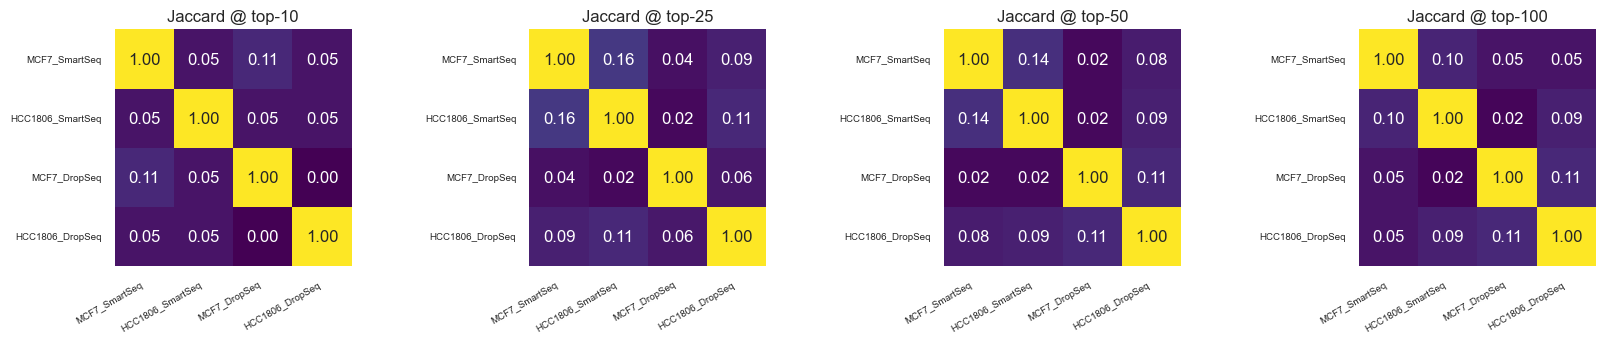

In [26]:
# Pairwise Jaccard of the top-K lists at a few thresholds. If a universal
# signature exists we'd expect the two same-technology off-diagonal cells (the
# two cell lines) to stay bright as K shrinks.
def jaccard(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(a | b)


names = list(DATASETS)
fig, axes = plt.subplots(1, len(KS), figsize=(4.2 * len(KS), 3.6))
for ax, k in zip(axes, KS):
    J = pd.DataFrame(
        [[jaccard(top_genes(a, k), top_genes(b, k)) for b in names] for a in names],
        index=names,
        columns=names,
    )
    sns.heatmap(J, annot=True, fmt=".2f", vmin=0, vmax=1, cmap="viridis", cbar=False, ax=ax, square=True)
    ax.set_title(f"Jaccard @ top-{k}")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=7)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

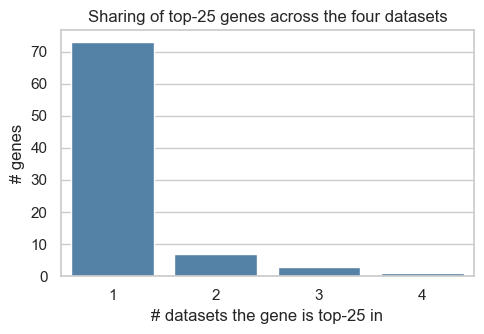

In all four datasets : ['PGK1']
In three of four     : ['BNIP3', 'LDHA', 'NDRG1']


In [ ]:
# How many of the four datasets does each top-25 gene appear in? This is the
# poor-man's UpSet plot: a bar chart of intersection sizes tells the same story
# without pulling in the upsetplot package.
K = 25
all_top = sorted(set().union(*[top_genes(n, K) for n in names]))
membership = pd.Series(0, index=all_top, dtype=int)
for n in names:
    membership[top_genes(n, K)] += 1

hist = membership.value_counts().sort_index()
plt.figure(figsize=(5, 3.5))
sns.barplot(x=hist.index, y=hist.values, color="steelblue")
plt.xlabel("# datasets the gene is top-25 in")
plt.ylabel("# genes")
plt.title(f"Sharing of top-{K} genes across the four datasets")
plt.tight_layout()
plt.show()

print("In all four datasets :", sorted(membership[membership == 4].index))
print("In three of four     :", sorted(membership[membership == 3].index))

In [ ]:
shared = set.intersection(*[set(f_rank[n].index) for n in names])
pct = pd.DataFrame({n: f_rank[n].rank(pct=True).reindex(shared) for n in names})
pct["mean_pct"] = pct.mean(axis=1)
consensus = pct.sort_values("mean_pct", ascending=False)

HIF_TARGETS = {
    "VEGFA",
    "CA9",
    "BNIP3",
    "BNIP3L",
    "LDHA",
    "SLC2A1",
    "SLC2A3",
    "PDK1",
    "PGK1",
    "ALDOA",
    "ALDOC",
    "ENO1",
    "ENO2",
    "GPI",
    "PFKFB3",
    "PFKP",
    "HK2",
    "NDRG1",
    "DDIT4",
    "EGLN1",
    "EGLN3",
    "P4HA1",
    "PLOD2",
    "BHLHE40",
    "ERO1A",
    "FAM162A",
    "TPI1",
    "GAPDH",
}
consensus["known_HIF_target"] = consensus.index.isin(HIF_TARGETS)
consensus.head(20).round(2)

,MCF7_SmartSeq,HCC1806_SmartSeq,MCF7_DropSeq,HCC1806_DropSeq,mean_pct,known_HIF_target
PGK1,1.00,1.00,1.00,0.99,1.00,True
TMSB10,0.94,0.97,1.00,1.00,0.98,False
DSP,0.99,0.96,0.97,0.97,0.97,False
MT-CYB,1.00,0.95,0.98,0.90,0.96,False
MT-CO3,1.00,0.93,0.98,0.87,0.94,False
LGALS1,0.83,0.93,1.00,0.96,0.93,False
HES1,0.79,0.99,0.99,0.91,0.92,False
CALM2,0.85,0.87,0.95,0.99,0.92,False
MT-CO2,1.00,0.70,0.98,0.92,0.90,False
MT-RNR1,0.85,0.92,0.99,0.76,0.88,False


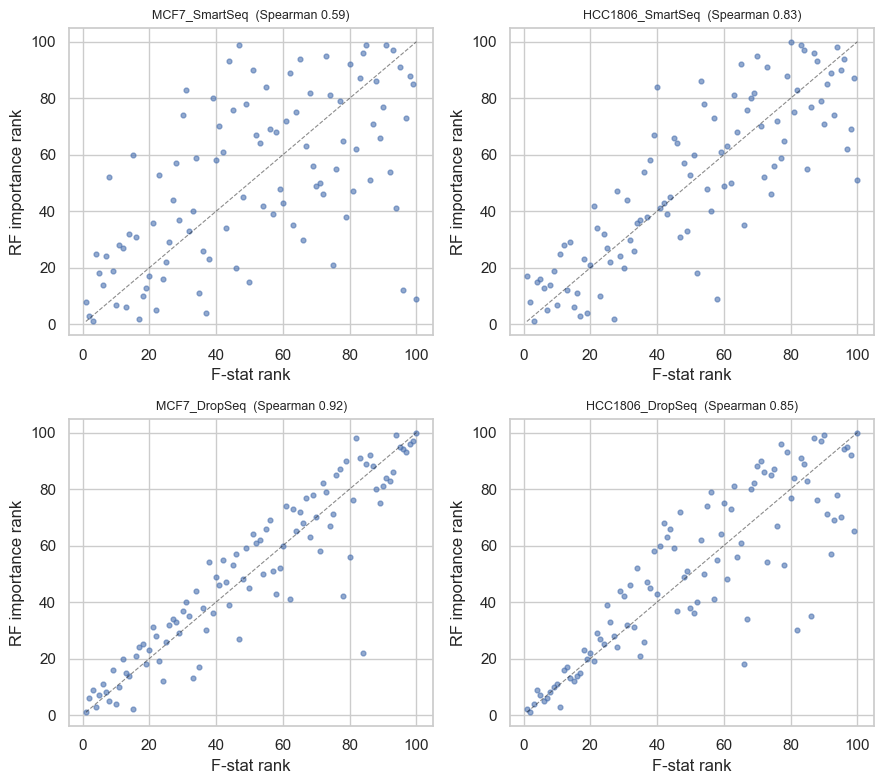

In [29]:
# Does the gene ranking depend on the method? ANOVA F scores linear, univariate
# separation; Random Forest importance (Gini) can reward genes that only matter
# in combination. A high rank-correlation means the per-dataset ranking is
# robust and not just an artefact of how we score a gene.
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for ax, ds_name in zip(axes.ravel(), names):
    X_df, y_ser = DATASETS[ds_name]()
    y = LabelEncoder().fit_transform(y_ser)
    rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RNG).fit(X_df.values, y)
    rf_imp = pd.Series(rf.feature_importances_, index=X_df.columns)

    top100 = f_rank[ds_name].index[:100]
    f_rk = f_rank[ds_name][top100].rank(ascending=False)  # 1 = strongest
    rf_rk = rf_imp[top100].rank(ascending=False)
    rho = spearmanr(f_rk, rf_rk).correlation

    ax.scatter(f_rk, rf_rk, s=12, alpha=0.6)
    ax.plot([1, 100], [1, 100], "k--", lw=0.8, alpha=0.5)
    ax.set_title(f"{ds_name}  (Spearman {rho:.2f})", fontsize=9)
    ax.set_xlabel("F-stat rank")
    ax.set_ylabel("RF importance rank")
plt.tight_layout()
plt.show()

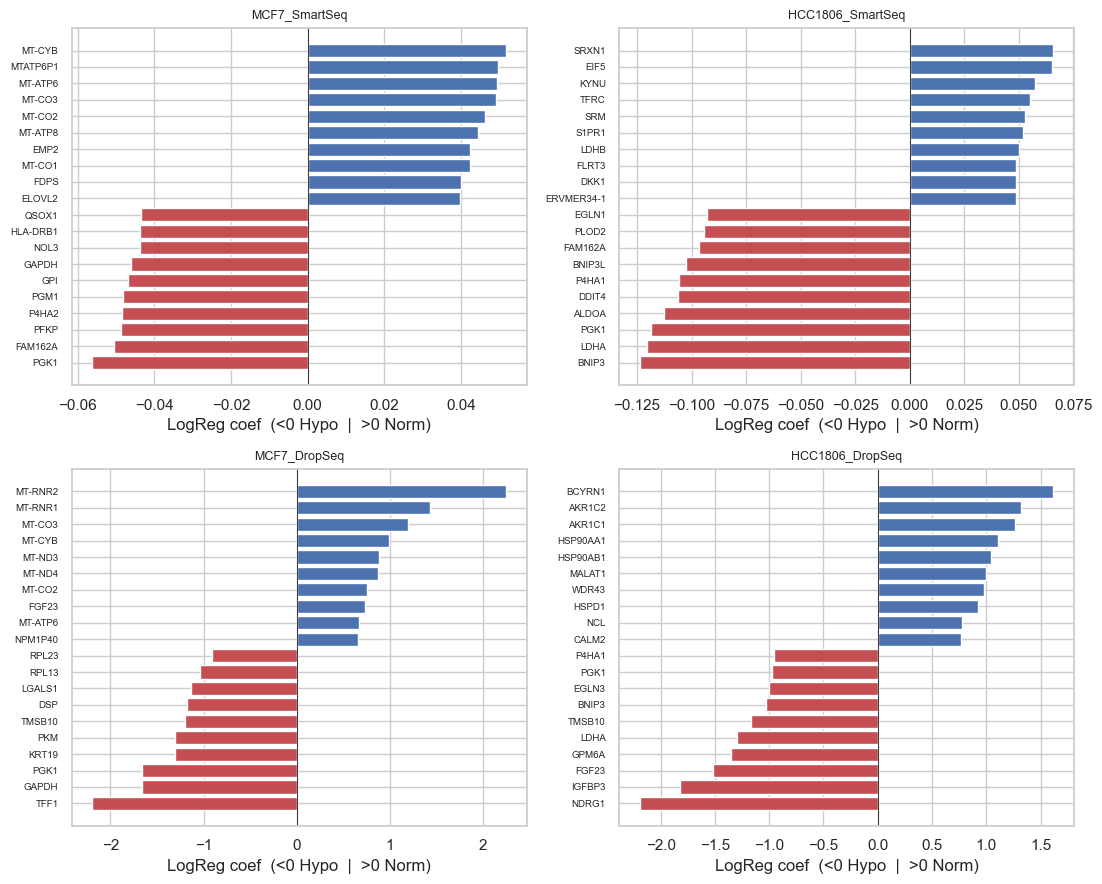

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, ds_name in zip(axes.ravel(), names):
    X_df, y_ser = DATASETS[ds_name]()
    le = LabelEncoder().fit(y_ser)
    lr = Pipeline([("scale", StandardScaler()), ("clf", LogisticRegression(max_iter=2000, random_state=RNG))])
    lr.fit(X_df.values, le.transform(y_ser))
    coef = pd.Series(lr.named_steps["clf"].coef_[0], index=X_df.columns).sort_values()
    show = pd.concat([coef.head(10), coef.tail(10)])  # 10 most Hypo + 10 most Norm
    colors = ["#c44e52" if c < 0 else "#4c72b0" for c in show]
    ax.barh(range(len(show)), show.values, color=colors)
    ax.set_yticks(range(len(show)))
    ax.set_yticklabels(show.index, fontsize=7)
    ax.axvline(0, color="k", lw=0.6)
    ax.set_title(ds_name, fontsize=9)
    ax.set_xlabel("LogReg coef  (<0 Hypo  |  >0 Norm)")
plt.tight_layout()
plt.show()

**What the overlap analysis says**

- The top-25 lists barely overlap as raw sets. Only **PGK1** lands in the
  top-25 of all four datasets, with BNIP3, LDHA and NDRG1 in three of four.
  Pairwise Jaccard is highest between the two SmartSeq cell lines and lowest
  wherever DropSeq is involved, which is as much a technology effect as biology
  (the DropSeq top lists are heavy with ribosomal/mitochondrial genes).
- The percentile-rank consensus (on the ~70 shared genes) is led by PGK1 but is
  otherwise dominated by housekeeping/metabolic and mitochondrial genes rather
  than canonical HIF targets. So a *strict* universal signature is weak: the
  robust cross-dataset signal is mostly general metabolic state, not a clean
  hypoxia program shared gene-for-gene.
- F-stat and RF rankings agree reasonably (Spearman ~0.6–0.9), so the
  per-dataset gene ranking isn't an artefact of the scoring method.

## 8 — Cross-dataset transfer: does a model trained on one cell line generalise?

The within-dataset scores in sections 3 and 5 are high, but that only shows
each model learned *its own* dataset. The real test of a universal signature is
transfer: train on one cell line and predict the other, using only the genes
the two share. We stay within a technology — cross-technology overlap is a few
hundred genes, too thin to be worth it (see the Jaccard heatmaps in 7).

In [33]:
TRANSFER = [
    ("MCF7_SmartSeq", "HCC1806_SmartSeq"),
    ("HCC1806_SmartSeq", "MCF7_SmartSeq"),
    ("MCF7_DropSeq", "HCC1806_DropSeq"),
    ("HCC1806_DropSeq", "MCF7_DropSeq"),
]
transfer_records = []
for src, dst in TRANSFER:
    Xs, ys = DATASETS[src]()
    Xd, yd = DATASETS[dst]()
    genes = [g for g in Xs.columns if g in set(Xd.columns)]  # shared, kept in src order
    le = LabelEncoder().fit(pd.concat([ys, yd]))
    y_dst = le.transform(yd)
    for model_name, model in make_models().items():
        model.fit(Xs[genes].values, le.transform(ys))
        proba = model.predict_proba(Xd[genes].values)[:, 1]
        pred = model.predict(Xd[genes].values)
        transfer_records.append(
            {
                "train": src,
                "test": dst,
                "model": model_name,
                "n_shared_genes": len(genes),
                "accuracy": accuracy_score(y_dst, pred),
                "f1": f1_score(y_dst, pred),
                "roc_auc": roc_auc_score(y_dst, proba),
            }
        )
    print(f"✓ transfer done for {src} -> {dst}")
transfer_df = pd.DataFrame(transfer_records)
transfer_df.round(3)

✓ transfer done for MCF7_SmartSeq -> HCC1806_SmartSeq
✓ transfer done for HCC1806_SmartSeq -> MCF7_SmartSeq
✓ transfer done for MCF7_DropSeq -> HCC1806_DropSeq
✓ transfer done for HCC1806_DropSeq -> MCF7_DropSeq


,train,test,model,n_shared_genes,accuracy,f1,roc_auc
0,MCF7_SmartSeq,HCC1806_SmartSeq,logreg,1208,0.560,0.658,0.741
1,MCF7_SmartSeq,HCC1806_SmartSeq,rf,1208,0.967,0.966,0.987
2,MCF7_SmartSeq,HCC1806_SmartSeq,svm_rbf,1208,0.533,0.000,0.479
3,HCC1806_SmartSeq,MCF7_SmartSeq,logreg,1208,0.596,0.365,0.887
4,HCC1806_SmartSeq,MCF7_SmartSeq,rf,1208,0.972,0.971,0.996
5,HCC1806_SmartSeq,MCF7_SmartSeq,svm_rbf,1208,0.512,0.062,0.838
6,MCF7_DropSeq,HCC1806_DropSeq,logreg,834,0.459,0.538,0.513
7,MCF7_DropSeq,HCC1806_DropSeq,rf,834,0.477,0.566,0.611
8,MCF7_DropSeq,HCC1806_DropSeq,svm_rbf,834,0.459,0.545,0.525
9,HCC1806_DropSeq,MCF7_DropSeq,logreg,834,0.671,0.676,0.776


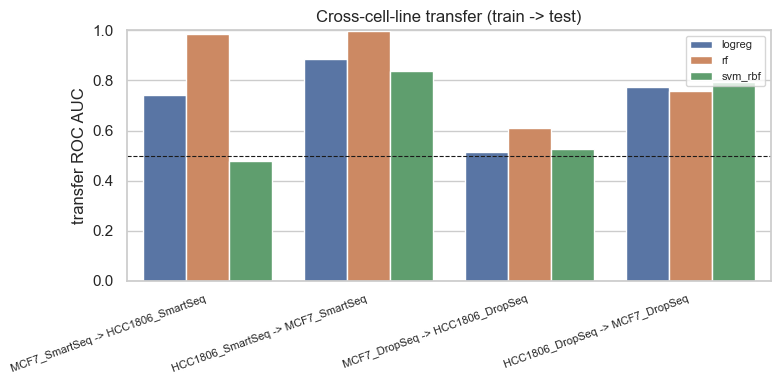

In [36]:
transfer_df = transfer_df.assign(pair=transfer_df["train"] + " -> " + transfer_df["test"])
plt.figure(figsize=(8, 4))
sns.barplot(data=transfer_df, x="pair", y="roc_auc", hue="model")
plt.axhline(0.5, ls="--", color="k", lw=0.8)
plt.ylim(0, 1)
plt.ylabel("transfer ROC AUC")
plt.xlabel("")
plt.xticks(rotation=20, ha="right", fontsize=8)
plt.title("Cross-cell-line transfer (train -> test)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

Transfer is mediocre to poor and very model-dependent: ROC AUC falls from the
~0.97–1.0 we saw within-dataset to anywhere between chance and ~0.9 across cell
lines, and accuracy/F1 collapse outright in the DropSeq MCF7 -> HCC1806
direction. Random Forest travels best (it leans on the recurring core genes),
while the RBF-SVM — tied to PCA axes fit on the source — barely beats chance. A
model trained on one cell line does *not* reliably read hypoxia in another, even
within the same technology and on shared genes.